## 유효한 변수 선택

In [1]:
from xgboost import XGBRegressor
import os
import glob
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
df_all = pd.read_csv("all_data.csv")
df_all

,bbox_x1,bbox_y1,bbox_x2,bbox_y2,conf,class,median_m,angular_z,imu_gyro_z,imu_acc_x,...,ratio_diff,log_bbox_width,log_bbox_height,log_bbox_area,log_ratio_w,log_ratio_h,log_ratio_mean,log_ratio_area,log_ratio_diag,source_file
0,406.343628,319.237488,422.137848,343.154999,0.750268,0,1.0610,0.000186,0.000000,-0.008978,...,0.363065,2.759644,3.174611,5.934255,-2.664320,-1.866272,-2.187712,-4.530519,-2.004881,preprocessed_SoldierFront100-110.csv
1,338.622772,320.997101,353.408875,344.326141,0.736244,0,1.0620,0.000186,0.000000,-0.008978,...,0.336509,2.693688,3.149699,5.843387,-2.598364,-1.841360,-2.149878,-4.439659,-1.967858,preprocessed_SoldierFront100-110.csv
2,406.425507,319.276794,422.063110,343.386627,0.748280,0,1.0610,0.000186,0.000000,0.043096,...,0.351301,2.749679,3.182620,5.932298,-2.654354,-1.874280,-2.190107,-4.528563,-2.007500,preprocessed_SoldierFront100-110.csv
3,338.809448,321.090179,353.351593,344.466187,0.730411,0,1.0610,0.000186,0.000000,0.043096,...,0.324800,2.677051,3.151710,5.828761,-2.581728,-1.843371,-2.145897,-4.425035,-1.964596,preprocessed_SoldierFront100-110.csv
4,406.428711,319.309479,422.181030,343.338165,0.748989,0,1.0610,0.000186,0.000000,0.043096,...,0.358266,2.756988,3.179248,5.936236,-2.661663,-1.870909,-2.190080,-4.532500,-2.007315,preprocessed_SoldierFront100-110.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,337.111603,316.819244,400.950653,345.951233,0.755896,1,1.0260,0.200513,0.177721,-0.122703,...,0.585312,4.156365,3.371837,7.528202,-2.488646,-2.177906,-2.321254,-4.666466,-2.419413,preprocessed_TankSide95-105.csv
646,615.525635,313.758240,639.000000,367.489532,0.528726,1,0.9575,0.200513,0.191556,-0.117316,...,1.169176,3.155909,3.983996,7.139905,-1.488198,-2.790057,-1.940734,-4.278203,-2.239803,preprocessed_TankSide95-105.csv
647,595.601685,313.960632,639.000000,364.689484,0.475336,1,0.9870,0.200513,0.191556,-0.117316,...,0.750565,3.770421,3.926495,7.696915,-2.102706,-2.732557,-2.368841,-4.835160,-2.369561,preprocessed_TankSide95-105.csv
648,588.698120,315.298706,639.000000,343.233093,0.722314,1,1.0280,-0.273218,0.208583,-0.129885,...,0.194655,3.918042,3.329858,7.247901,-2.250326,-2.135928,-2.191492,-4.386191,-2.220910,preprocessed_TankSide95-105.csv


In [3]:
from sklearn.ensemble import RandomForestRegressor

def rf_model(seed):
    return RandomForestRegressor(
        n_estimators=100,
        random_state=seed,
        n_jobs=-1
    )

def xg_model(seed):
    return XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=seed,
    n_jobs=-1
)


def evaluate_with_seeds(model_fn, X, y, seeds=range(10), test_size=0.2):
    maes, rmses, r2s = [], [], []

    for seed in seeds:
        # split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=seed
        )

        # 모델 생성 (seed마다 새로)
        model = model_fn(seed)

        # 학습
        model.fit(X_train, y_train)

        # 예측
        y_pred = model.predict(X_test)

        # metric 계산
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        maes.append(mae)
        rmses.append(rmse)
        r2s.append(r2)

    # 평균 + 표준편차
    print("\n[RESULT]")
    print(f"MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
    print(f"RMSE: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
    print(f"R2  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

    return

In [6]:
# target 변수 제외
# 데이터 전처리

feature_cols = [col for col in df_all.columns if col != 'median_m' and col != "source_file"]


X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

## RF Feature Importance


[RESULT]
MAE : 0.0269
RMSE: 0.0467
R2  : 0.9661


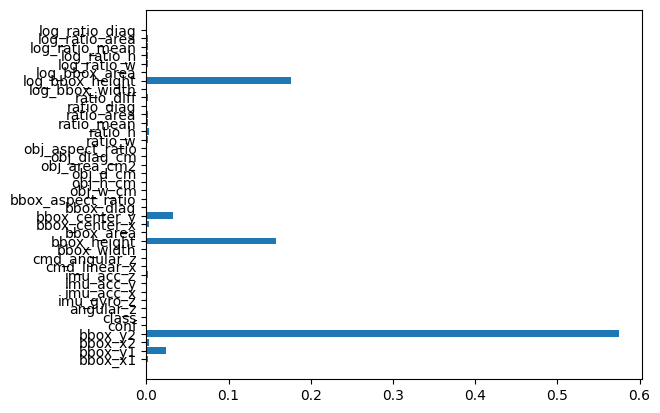

In [7]:
import matplotlib.pyplot as plt
rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()

## 필요한 변수들만을 이용해서


[RESULT]
MAE : 0.0185
RMSE: 0.0309
R2  : 0.9872


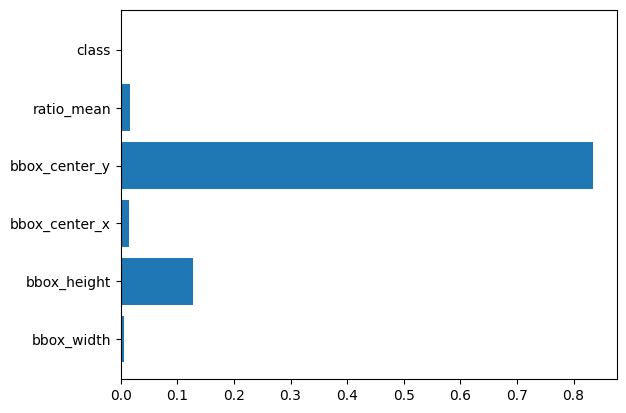

In [11]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "bbox_center_y",
    "ratio_mean",
    "class",
    
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()


[RESULT]
MAE : 0.0387
RMSE: 0.0693
R2  : 0.9359


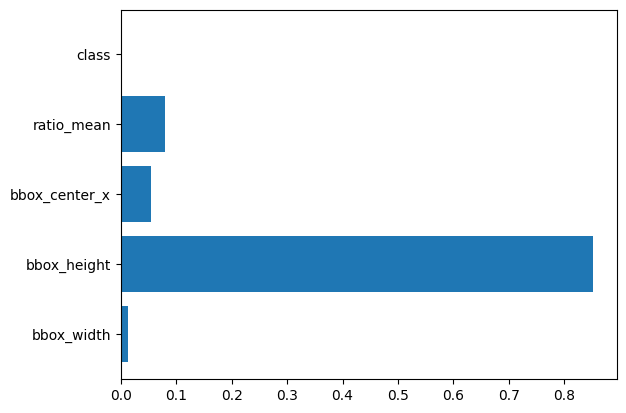

In [12]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",
    "class",
    
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()

In [14]:
evaluate_with_seeds(rf_model, X, y)


[RESULT]
MAE : 0.0378 ± 0.0032
RMSE: 0.0649 ± 0.0089
R2  : 0.9400 ± 0.0186


In [15]:
evaluate_with_seeds(xg_model, X, y)


[RESULT]
MAE : 0.0389 ± 0.0035
RMSE: 0.0668 ± 0.0071
R2  : 0.9371 ± 0.0153



[RESULT]
MAE : 0.0395
RMSE: 0.0704
R2  : 0.9337


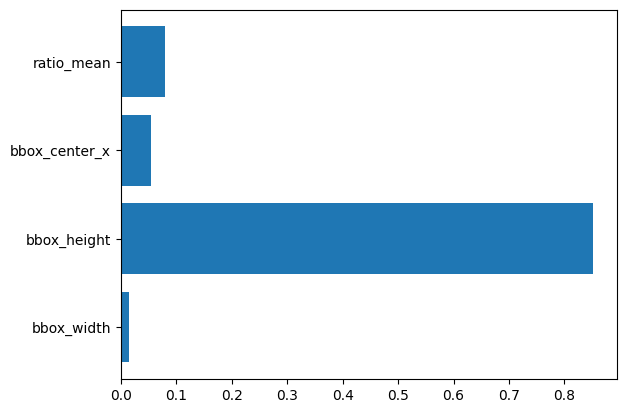

In [18]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",    
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()

In [19]:
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)


[RESULT]
MAE : 0.0381 ± 0.0032
RMSE: 0.0653 ± 0.0090
R2  : 0.9394 ± 0.0189

[RESULT]
MAE : 0.0398 ± 0.0033
RMSE: 0.0677 ± 0.0076
R2  : 0.9353 ± 0.0169



[RESULT]
MAE : 0.0396
RMSE: 0.0708
R2  : 0.9330


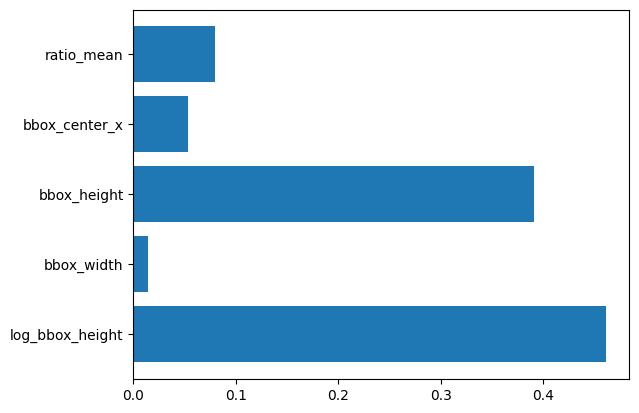

In [ ]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "log_bbox_height",
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",    
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()

In [20]:
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)


[RESULT]
MAE : 0.0381 ± 0.0032
RMSE: 0.0653 ± 0.0090
R2  : 0.9394 ± 0.0189

[RESULT]
MAE : 0.0398 ± 0.0033
RMSE: 0.0677 ± 0.0076
R2  : 0.9353 ± 0.0169



[RESULT]
MAE : 0.0396
RMSE: 0.0708
R2  : 0.9330


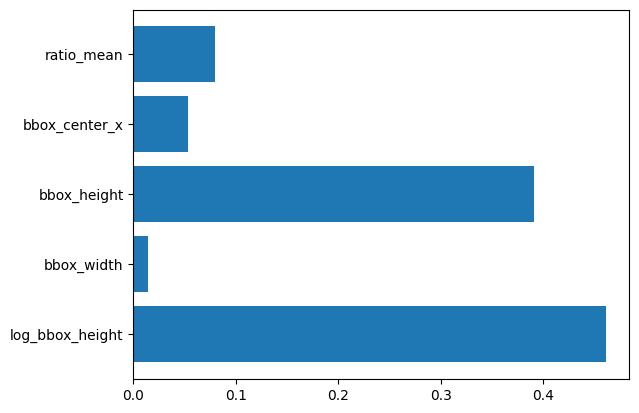


[RESULT]
MAE : 0.0381 ± 0.0032
RMSE: 0.0653 ± 0.0089
R2  : 0.9394 ± 0.0186

[RESULT]
MAE : 0.0392 ± 0.0037
RMSE: 0.0664 ± 0.0082
R2  : 0.9375 ± 0.0174


In [30]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "log_bbox_height",
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",  
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()


evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)


[RESULT]
MAE : 0.0386
RMSE: 0.0701
R2  : 0.9342


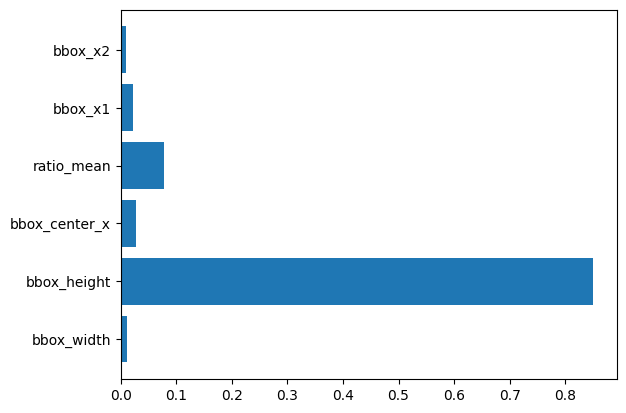


[RESULT]
MAE : 0.0379 ± 0.0034
RMSE: 0.0651 ± 0.0090
R2  : 0.9397 ± 0.0187

[RESULT]
MAE : 0.0391 ± 0.0034
RMSE: 0.0664 ± 0.0082
R2  : 0.9376 ± 0.0172


In [4]:
# target 변수 제외
# 데이터 전처리

feature_cols = [
    "bbox_width",
    "bbox_height",
    "bbox_center_x",
    "ratio_mean",  
    "bbox_x1",
    "bbox_x2",
]

X = df_all[feature_cols].copy()
y = df_all["median_m"].copy()


X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43
)


X_train = pd.DataFrame(
    X_train,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test,
    columns=X_test.columns,
    index=X_test.index
)

rf = RandomForestRegressor(
        n_estimators=100,
        random_state=46,
        n_jobs=-1
    )
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n[RESULT]")
print(f"MAE : {np.mean(mae):.4f}")
print(f"RMSE: {np.mean(rmse):.4f}")
print(f"R2  : {np.mean(r2):.4f}")


importances = rf.feature_importances_
plt.barh(X_train.columns, importances)
plt.show()
evaluate_with_seeds(rf_model, X, y)
evaluate_with_seeds(xg_model, X, y)